In [15]:
import os
import sys
from pathlib import Path

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd()
for candidate in [project_root, *project_root.parents]:
    if (candidate / "src").exists():
        project_root = candidate
        break

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.models.model import CMAPSSModel
from src.data.dataloader import get_dataloaders
from src.data.datasetclass import CMAPSSDataset
from torch.utils.data import DataLoader

model = CMAPSSModel(input_size=24, hidden_size=128)
model_path = project_root / "models" / "model.pt"
model.load_state_dict(torch.load(model_path, map_location="cpu"))
model.eval()

C:\Users\dines\AppData\Local\Temp\ipykernel_12660\3484262637.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location="

CMAPSSModel(
  (lstm): LSTM(24, 128, batch_first=True)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)

In [22]:
df = pd.read_parquet(r"C:\MLE\aerospace_mle\datasets\processed\output_parquet.parquet")
unique_engine_ids = df["global_engine_id"].unique()
rng = np.random.default_rng(42)
rng.shuffle(unique_engine_ids)
split_idx = int(len(unique_engine_ids) * 0.8)
unique_engine_ids = df["global_engine_id"].unique()
single_engine_id = unique_engine_ids[-1] 
single_engine_df = df[df["global_engine_id"] == single_engine_id].copy()
single_engine_dataset = CMAPSSDataset(dataframe=single_engine_df, window_size=30)


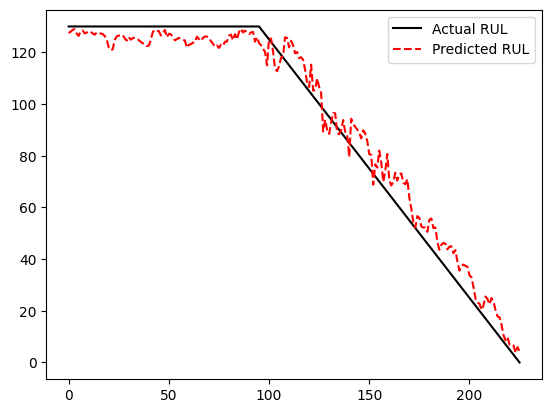

In [26]:
actual_rul = []
predicted_rul = []

for x, y in single_engine_dataset:
    actual_rul.append(float(y))
    x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        predicted = model(x)
    predicted_rul.append(float(predicted.item()))

plt.plot(actual_rul, label="Actual RUL", color="black")
plt.plot(predicted_rul, label="Predicted RUL", color="red", linestyle="dashed")
plt.legend()
plt.show()